In [168]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import xarray as xr
import numpy as np
import pandas as pd
from scipy.special import expit 
import os

#load data and filter during growing season
df = pyreadr.read_r("/glade/derecho/scratch/brendanc/VPD/Data_TreeNet_daily.rds")[None]
df = df[(df.doy >= 91) & (df.doy <= 273)].copy()

#select species
mask = (df.species.str.lower() == "quercus pubescens")
df = df.loc[mask].copy()

#transform growth vs non growth to 1 and 0 for binomial GLM
df["grow"] = (df["dGRO.yr"]>0).astype(int)

#list of independent variables
predictors = ["temp", "vpd", "rad", "total_precip", "swp", "Daylength"]

#drop nans
work = df[["grow", "station"] + predictors].dropna().copy()

#compute means and SDs, drop zero‐variance predictors
mu = work[predictors].mean()
sd = work[predictors].std()
zero_vars = sd[sd == 0.0].index.tolist()
if zero_vars:
    print("Dropping constant predictors:", zero_vars)
    predictors = [v for v in predictors if v not in zero_vars]

#standardize remaining predictors
work[predictors] = (work[predictors] - work[predictors].mean()) / work[predictors].std()

#construct formula with vpd:swp interaction
rhs = "Daylength*(" + "+".join(v for v in predictors if v != "Daylength") + ") + vpd:swp"
formula = "grow ~ " + rhs
print("Model formula:", formula)

#covariance type
stations = work["station"].unique()
if len(stations) > 1:
    cov_type = "cluster"
    cov_kwds = {"groups": work["station"]}
else:
    cov_type = "HC0"
    cov_kwds = {}

#fit the GLM
glm = smf.glm(formula,
              data=work,
              family=sm.families.Binomial()) \
        .fit(cov_type=cov_type,
             cov_kwds=cov_kwds)

# glm summary
print(glm.summary())

Model formula: grow ~ Daylength*(temp+vpd+rad+total_precip+swp) + vpd:swp
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   grow   No. Observations:                11066
Model:                            GLM   Df Residuals:                    11053
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4184.7
Date:                Thu, 05 Feb 2026   Deviance:                       8369.3
Time:                        12:23:27   Pearson chi2:                 1.14e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1857
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

In [170]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrix

# 1) Build training data in raw units

predictors = ["vpd","temp","rad","total_precip","swp","Daylength"]
cols = ["grow","station"] + predictors
work_raw = df[cols].dropna().copy()

for c in predictors:
    work_raw[c] = pd.to_numeric(work_raw[c], errors="coerce")
work_raw = work_raw.dropna(subset=predictors + ["grow"])

y = work_raw["grow"].astype(float)
X = work_raw[predictors].reset_index(drop=True)

#species, swp filter, vpd filter, vpd dof, swp dof
#picea abies: none, none, 5, 3
#abies alba: -450, none, 5, 3
#pinus sylvestris: -1750, none, 5, 3
#fagus sylvatica: none, none, 5, 3
#quercus petraea: none, none, 4, 3
#fraxinus excelsior: none, none, 5, 3
#quercus pubescens: -1750, none, 4, 3

fit_mask = work_raw["swp"] >= -1750.0    
work_raw   = work_raw.loc[fit_mask].copy()

#fit_mask = work_raw["vpd"] <= 1.5  
#work_raw   = work_raw.loc[fit_mask].copy()

y = work_raw["grow"].astype(float).to_numpy()
X = work_raw[predictors].reset_index(drop=True)

# 2) Natural cubic splines on vpd and swp

s_vpd = dmatrix(f"cr(vpd, df={4}) - 1", data=X, return_type="dataframe")
s_swp = dmatrix(f"cr(swp, df={3}) - 1", data=X, return_type="dataframe")

# Keep design info (for prediction/plots later)
design_vpd = s_vpd.design_info
design_swp = s_swp.design_info

# Linear terms (raw units)
X_lin = X[["temp","rad","total_precip","Daylength"]].reset_index(drop=True)

# Full design matrix: [vpd splines][swp splines][linear cols]
EXOG = pd.concat(
    [
        s_vpd.reset_index(drop=True),
        s_swp.reset_index(drop=True),
        X_lin,
    ],
    axis=1
)

# 3) Fit the GLM (Binomial logit), with clustered SE by station if >1
if work_raw["station"].nunique() > 1:
    cov_type = "cluster"
    cov_kwds = {"groups": work_raw["station"]}
else:
    cov_type = "HC0"
    cov_kwds = {}

glm_ns = sm.GLM(y, EXOG.values, family=sm.families.Binomial()).fit(
    cov_type=cov_type, cov_kwds=cov_kwds
)
print(glm_ns.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                10240
Model:                            GLM   Df Residuals:                    10230
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3943.7
Date:                Thu, 05 Feb 2026   Deviance:                       7887.5
Time:                        12:23:38   Pearson chi2:                 9.05e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1829
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -3.0376    3.2e+06  -9.48e-07      1.0

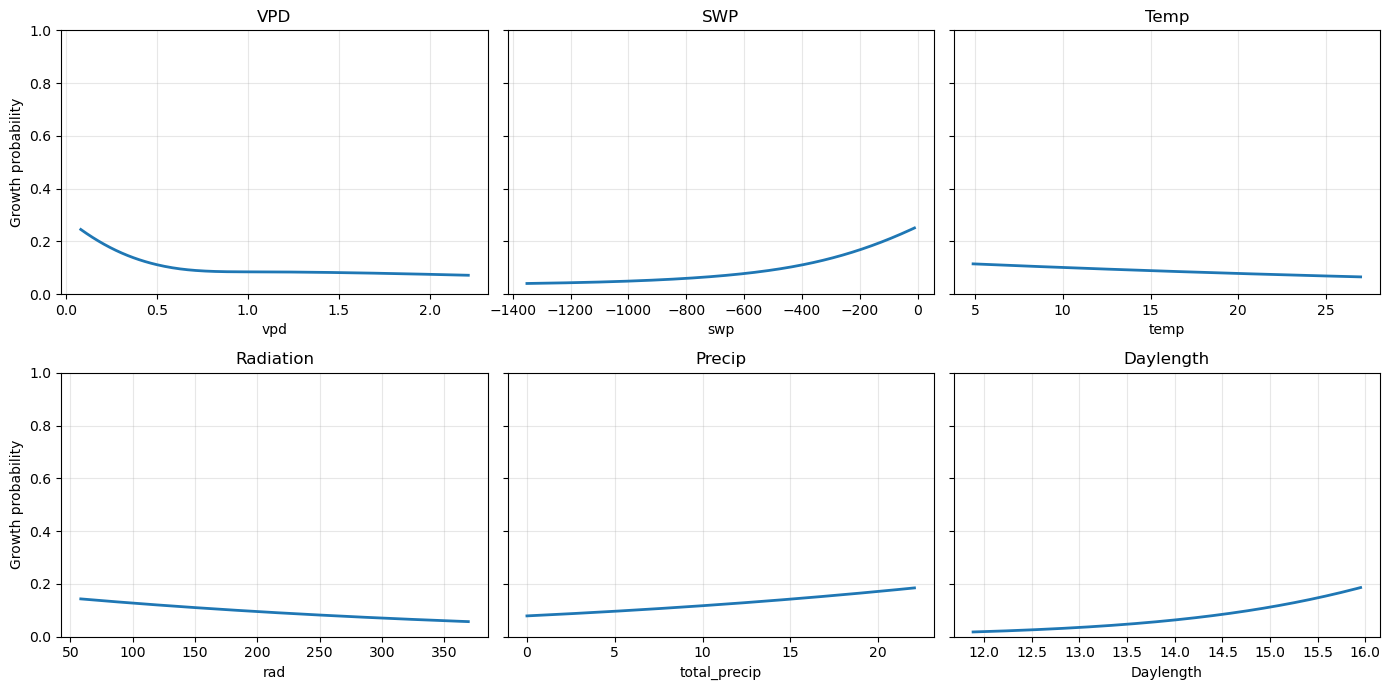

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patsy import build_design_matrices

# Assumes you already have:
# - glm_ns        : fitted statsmodels GLM
# - design_vpd    : patsy DesignInfo for vpd spline
# - design_swp    : patsy DesignInfo for swp spline
# - X             : training DataFrame with raw predictors
#
# Training order: [vpd splines][swp splines][temp, rad, total_precip, Daylength]

spline_vars = ["vpd", "swp"]
linear_vars = ["temp", "rad", "total_precip", "Daylength"]
all_vars    = spline_vars + linear_vars

designs = {"vpd": design_vpd, "swp": design_swp}

# Reference context (means of training data)
ref = X[all_vars].mean()

def _build_exog(df_pred):
    """Rebuild EXOG in the SAME column order used during training."""
    blocks = []
    for var in spline_vars:
        [B] = build_design_matrices([designs[var]], df_pred)
        blocks.append(np.asarray(B))
    blocks.append(df_pred[linear_vars].to_numpy())
    return np.column_stack(blocks)

def _predict_curve(var, n=200, use_quantiles=True):
    """Predict growth probability while varying a spline var."""
    if use_quantiles:
        lo, hi = X[var].quantile([0.01,0.99]).to_numpy()
    else:
        lo, hi = X[var].min(), X[var].max()
    grid = np.linspace(lo, hi, n)
    df_pred = pd.DataFrame({v: np.full_like(grid, ref[v], dtype=float) for v in all_vars})
    df_pred[var] = grid
    EXOG_new = _build_exog(df_pred)
    yhat = glm_ns.predict(EXOG_new)
    return grid, yhat

def _predict_line(var, n=200, use_quantiles=True):
    """Predict growth probability while varying a linear var."""
    if use_quantiles:
        lo, hi = X[var].quantile([0.01,0.99]).to_numpy()
    else:
        lo, hi = X[var].min(), X[var].max()
    grid = np.linspace(lo, hi, n)
    df_pred = pd.DataFrame({v: np.full_like(grid, ref[v], dtype=float) for v in all_vars})
    df_pred[var] = grid
    EXOG_new = _build_exog(df_pred)
    yhat = glm_ns.predict(EXOG_new)
    return grid, yhat

# Plot curves (vpd, swp) and lines (temp, rad, precip, daylength)
vars_to_plot = spline_vars + linear_vars
titles = {
    "vpd": "VPD",
    "swp": "SWP",
    "temp": "Temp",
    "rad": "Radiation",
    "total_precip": "Precip",
    "Daylength": "Daylength"
}

nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14,7), sharey=True)
axes = axes.ravel()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    if var in spline_vars:
        x, y = _predict_curve(var)
        ax.plot(x, y, lw=2)
    else:
        x, y = _predict_line(var)
        ax.plot(x, y, lw=2)
    ax.set_title(titles[var])
    ax.set_xlabel(var)
    if i % ncols == 0:
        ax.set_ylabel("Growth probability")
    ax.set_ylim(0,1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [172]:
fd = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/ARISE_006'   
#fd = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/006'   
open_opts = dict(chunks={'time': 365})                    

temp   = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.cam.h1.TS.20350101-20691231.nc'
           ),
           **open_opts
         )['TS'] - 273.15                                  # K → °C
#temp = temp.sel(time=slice('2035-01-01', '2069-12-31'))

vpd    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.cam.h1.VPD.20350101-20691230.nc'
           ),
           **open_opts
         )['VPD'].clip(min=0)                                      # kPa, non-negative

rad    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.cam.h1.FSDS.20350101-20691231.nc'
           ),
           **open_opts
         )['FSDS']                                         # W m-2
#rad = rad.sel(time=slice('2035-01-01', '2069-12-31'))
precip = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.cam.h1.PRECT.20350101-20691231.nc'
           ),
           **open_opts
         )['PRECT'] * 8.64e7                               # kg m-2 s-1 → mm day-1
#precip = precip.sel(time=slice('2035-01-01', '2069-12-31'))
FACTOR_KPA = 9.80665e-3                                    # −ρg/1000 : mm → kPa
swp    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.clm2.h3.SMP.latlon.20350101-20691231.nc'
           ),
           **open_opts
         )['SMP_GRIDCELL'] * FACTOR_KPA                             # mm → kPa
#swp = swp.sel(time=slice('2015-01-01', '2069-12-30'))

/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [173]:
# Number of duplicate labels
idx = swp.get_index("time")          # pandas.DatetimeIndex
dupes = idx[idx.duplicated()]        # all duplicates (keeps second+ copies)
print(f"{dupes.size} duplicate dates found")

# See which dates are duplicated
print("Duplicated days:\n", dupes.unique())

0 duplicate dates found
Duplicated days:
 CFTimeIndex([], dtype='object', length=0, calendar=None, freq=None)


In [175]:
import xarray as xr

# --- 1.  Drop the second copy of every duplicate day --------------------
idx        = swp.indexes["time"]                 # CFTimeIndex
unique_sel = ~idx.duplicated()                   # keep FIRST occurrence
swp_clean  = swp.isel(time=unique_sel)           # length → 12 775

# --- 2.  (Optional) sanity-check: duplicates really gone ---------------
assert swp_clean.indexes["time"].is_unique
assert swp_clean.time.size == 12776

In [177]:
lat0, lon0 = temp.lat, temp.lon    
temp = temp.sortby('lat')
lat0 = temp.lat

In [178]:
def align_to(ds_var, lat_ref, lon_ref, method='nearest'):
    """
    Return ds_var reindexed onto lat_ref / lon_ref, preserving chunks.
    """
    ds_var = ds_var.sortby('lat')
    if not (np.array_equal(ds_var.lat, lat_ref) and np.array_equal(ds_var.lon, lon_ref)):
        ds_var = ds_var.interp(lat=lat_ref, lon=lon_ref, method=method)
    return ds_var

In [179]:
swp_clean = align_to(swp_clean , lat0, lon0)
precip = align_to(precip, lat0, lon0)
rad = align_to(rad, lat0, lon0)
vpd = align_to(vpd, lat0, lon0)

In [181]:
for name, da in zip(["temp", "vpd", "rad", "precip", "swp_clean"], 
                    [temp, vpd, rad, precip, swp_clean]):
    print(f"{name}: duplicates = {(~da['time'].to_index().is_unique)}")

temp: duplicates = -2
vpd: duplicates = -2
rad: duplicates = -2
precip: duplicates = -2
swp_clean: duplicates = -2


In [182]:
def drop_duplicate_time(da):
    _, index = np.unique(da['time'], return_index=True)
    return da.isel(time=index)

temp         = drop_duplicate_time(temp)
vpd          = drop_duplicate_time(vpd)
rad          = drop_duplicate_time(rad)
precip       = drop_duplicate_time(precip)
swp_clean    = drop_duplicate_time(swp_clean)

In [183]:
ds = xr.Dataset(
    dict(
        temp         = temp,
        vpd          = vpd,
        rad          = rad,
        total_precip = precip,
        swp          = swp_clean
    )
)

In [184]:
def daylength(doy, lat):
    lat_rad = np.deg2rad(lat)
    decl    = np.deg2rad(23.44) * np.sin(2*np.pi/365 * (doy - 81))
    arg     = np.clip(-np.tan(lat_rad) * np.tan(decl), -1.0, 1.0)
    h0      = np.arccos(arg)
    return 24.0/np.pi * h0          # hours

dl = xr.apply_ufunc(
        daylength,
        ds['time'].dt.dayofyear,
        ds['lat'],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
     )
ds['Daylength'] = dl.assign_attrs(units='h', long_name='astronomical day length')

In [185]:
ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')

In [186]:
#ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
europe = ds.sel(lat=slice(35, 72), lon=slice(-11, 40))
europe = europe.drop_vars([v for v in europe if europe[v].isnull().all()])

In [187]:
ds = europe

In [188]:
#ds = ds.sel(time=slice('2015-01-01', '2016-12-31'))

In [189]:
#europe_sel = europe['swp']
#europe_sel = europe_sel.sel(time='1993-01-01')
#europe_sel.plot()

In [190]:
import numpy as np
import pandas as pd
import xarray as xr
from patsy import build_design_matrices  

# If Daylength is 2D (time, lat), expand to (time, lat, lon) 
if set(ds["Daylength"].dims) == {"time","lat"}:
    ds["Daylength"] = ds["Daylength"].expand_dims(lon=ds["lon"]).transpose("time","lat","lon")

# Model structure used for training
smooth_cols = ["vpd","swp"]                               
linear_cols = ["temp","rad","total_precip","Daylength"]   
all_cols    = smooth_cols + linear_cols

#Build a single DataArray with a 'var' axis, then stack time/lat/lon
pred = ds[all_cols].to_array("var")                  # ('var','time','lat','lon')
pred = pred.transpose("time","lat","lon","var")      # ('time','lat','lon','var')
stacked = pred.stack(pixel=("time","lat","lon"))     # ('pixel','var')
stacked = stacked.transpose("pixel","var")           # ensure (pixel,var)

# Convert to DataFrame for patsy and statsmodels 
df_new = pd.DataFrame(stacked.values, columns=all_cols)

# Valid rows: need all predictors present (no nans)
need_cols = all_cols
valid_mask = df_new[need_cols].notna().all(axis=1)

# Prepare empty predictions (nan) and fill only for valid rows
p_vec = np.full(stacked.sizes["pixel"], np.nan, dtype=float)

if valid_mask.any():
    dfv = df_new.loc[valid_mask].copy()

    # Build the same spline bases that were used in training
    # design_vpd and design_swp must come from your training cell
    [s_vpd_new] = build_design_matrices([design_vpd], dfv)
    [s_swp_new] = build_design_matrices([design_swp], dfv)

    # Column-stack: [vpd splines][swp splines][linear cols]
    EXOG_new = np.column_stack([
        np.asarray(s_vpd_new),
        np.asarray(s_swp_new),
        dfv[linear_cols].to_numpy()
    ])

    # Predict only for valid pixels
    p_vec_valid = glm_ns.predict(EXOG_new)
    p_vec[valid_mask.to_numpy()] = p_vec_valid

# Unstack back to (time, lat, lon)
p_growth = xr.DataArray(
    p_vec.reshape(stacked.sizes["pixel"]),
    coords={"pixel": stacked["pixel"]},
    dims=("pixel",)
).unstack("pixel").transpose("time","lat","lon")

In [191]:
p_growth_slice = p_growth.sel(time='2036-09-01')

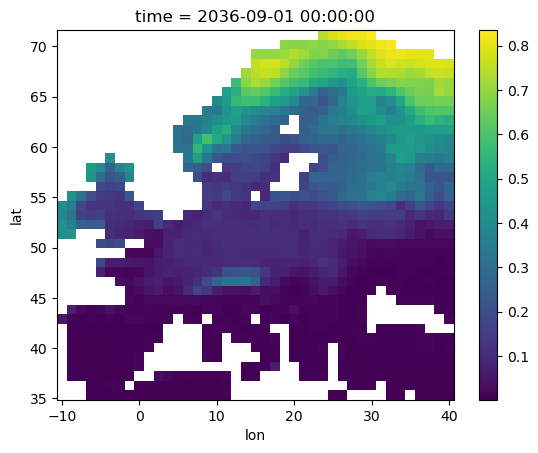

In [192]:
p_growth_slice.plot()

In [194]:
# mm per growth day, Table S2 Etzold et al.
picea_abies = 0.023
pinus_sylvestris = 0.018
abies_alba = 0.016
fagus_sylvatica = 0.009
fraxinus_excelsior = 0.016
quercus_petraea = 0.011
quercus_pubescens = 0.012

mu_inc = quercus_pubescens
daily_inc_mm = (p_growth * mu_inc).assign_attrs(
    long_name = "expected radial increment per day",
    units     = "mm day-1",
    note      = "p_growth × mean increment on growth days"
)
annual_inc_mm = (
    daily_inc_mm
      .groupby("time.year")
      .sum(dim="time")            # mm yr-1
      .rename(year="time")
      .assign_attrs(units="mm yr-1",
                    long_name="expected annual radial increment")
)

In [195]:
#annual_inc_mm_sel = annual_inc_mm.sel(time=1992)
#annual_inc_mm_sel.plot()

In [196]:
filedir = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'
annual_inc_mm.to_netcdf(filedir + '/quercus_pubescens_ARISE_Europe_annual_radial_growth_2035-2069_nonlin.nc')

In [ ]:
#Ensure nonlinearity

In [452]:
# training ranges (plain Python floats)
vpd_lo, vpd_hi   = float(work["vpd"].min()),  float(work["vpd"].max())
temp_lo, temp_hi = float(work["temp"].min()), float(work["temp"].max())

# boolean masks on the dask-backed xarray DataArrays
oob_vpd_da  = (ds.vpd  < vpd_lo)  | (ds.vpd  > vpd_hi)
oob_temp_da = (ds.temp < temp_lo) | (ds.temp > temp_hi)

# fractions as Python floats
frac_oob_vpd  = float(oob_vpd_da.mean().compute())
frac_oob_temp = float(oob_temp_da.mean().compute())

print(f"Training vpd range:  {vpd_lo:.3f} – {vpd_hi:.3f}")
print(f"Training temp range: {temp_lo:.3f} – {temp_hi:.3f}")
print(f"Fraction of ds pixels out-of-bounds for vpd:  {100*frac_oob_vpd:.2f}%")
print(f"Fraction of ds pixels out-of-bounds for temp: {100*frac_oob_temp:.2f}%")

Training vpd range:  -1.846 – 4.503
Training temp range: -2.938 – 2.790
Fraction of ds pixels out-of-bounds for vpd:  0.26%
Fraction of ds pixels out-of-bounds for temp: 87.52%


Text(0, 0.5, 'Predicted growth probability')

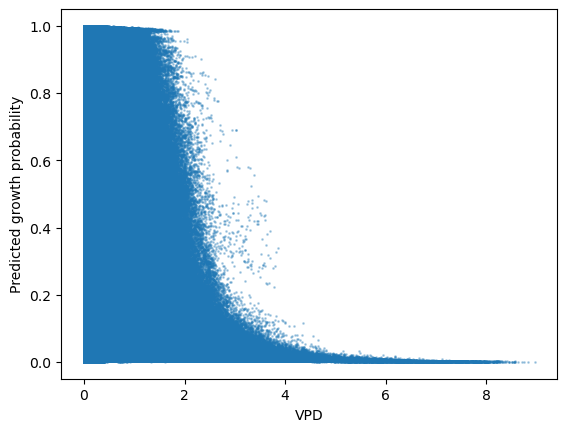

In [453]:
plt.scatter(dfv["vpd"], p_vec_valid, s=1, alpha=0.3)
plt.xlabel("VPD")
plt.ylabel("Predicted growth probability")

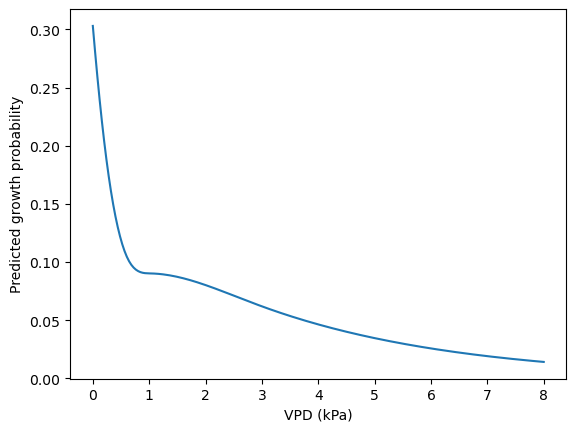

In [33]:
test_df = pd.DataFrame({
    "vpd": np.linspace(0, 8, 200),
    "swp": np.full(200, np.median(dfv["swp"])),
    "temp": np.full(200, np.median(dfv["temp"])),
    "rad": np.full(200, np.median(dfv["rad"])),
    "total_precip": np.full(200, np.median(dfv["total_precip"])),
    "Daylength": np.full(200, np.median(dfv["Daylength"]))
})

[s_vpd_test] = build_design_matrices([design_vpd], test_df)
[s_swp_test] = build_design_matrices([design_swp], test_df)
EXOG_test = np.column_stack([
    np.asarray(s_vpd_test),
    np.asarray(s_swp_test),
    test_df[["temp","rad","total_precip","Daylength"]].to_numpy()
])
yhat_test = glm_ns.predict(EXOG_test)

plt.plot(test_df["vpd"], yhat_test)
plt.xlabel("VPD (kPa)")
plt.ylabel("Predicted growth probability")
plt.show()